
##################################################################################################################################
START CLEAN UN MODEL + f_n CALIBRATION
##################################################################################################################################
K_d fixed             = 5.000000e+05 bub/m
rho_d default         = 3.0e13 m^-2
N_d0                  = 1.500000e+19 bub/m3
Xe yield              = 2.400000e-01
dt scan               = 12.00 h
n_modes               = 25
bulk seed radius      = 0.000 nm
Target principale: experimental large/P2 bubbles -> model dislocation bubbles.
Running f_n = 3.000e-10
Running f_n = 5.000e-10
Running f_n = 7.000e-10
Running f_n = 1.000e-09
Running f_n = 1.500e-09
Running f_n = 2.000e-09
Running f_n = 3.000e-09
Running f_n = 5.000e-09
Running f_n = 7.000e-09
Running f_n = 1.000e-08
Running f_n = 3.000e-08
Running f_n = 1.000e-07
Running f_n = 3.000e-07
Running f_n = 1.000e-06

RANKING f_n ONLY, K_d FIXED
ra

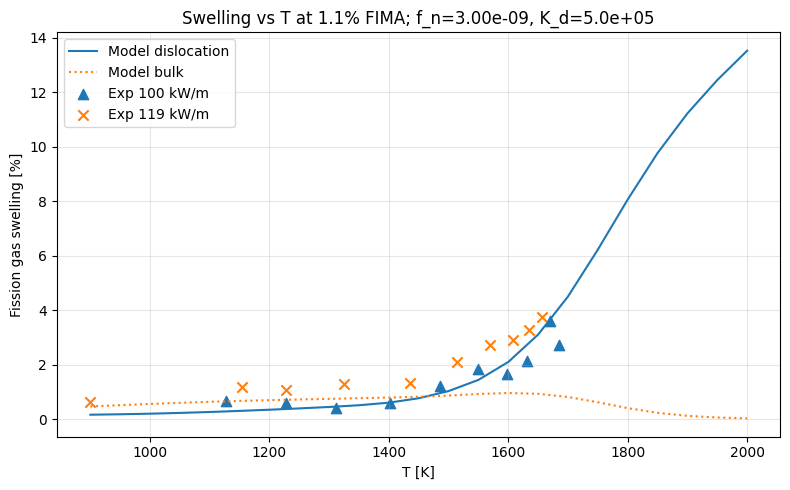

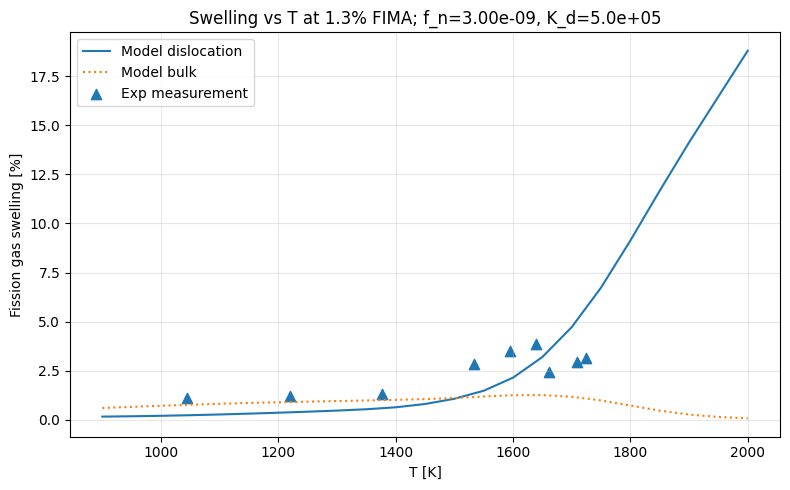

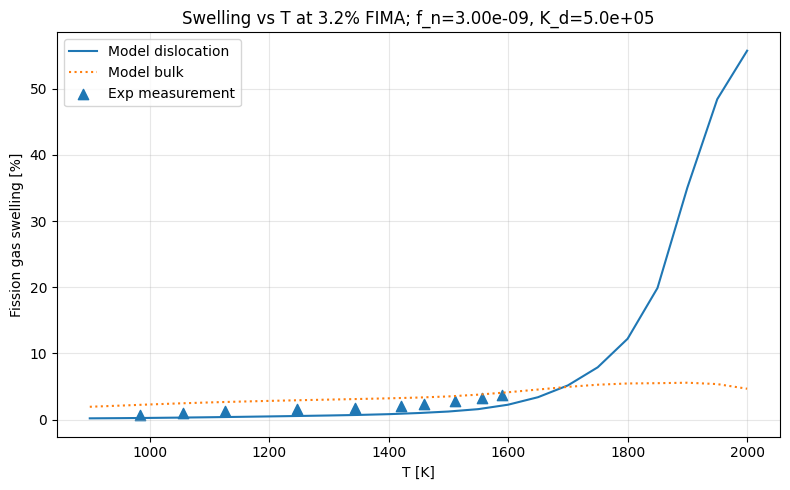

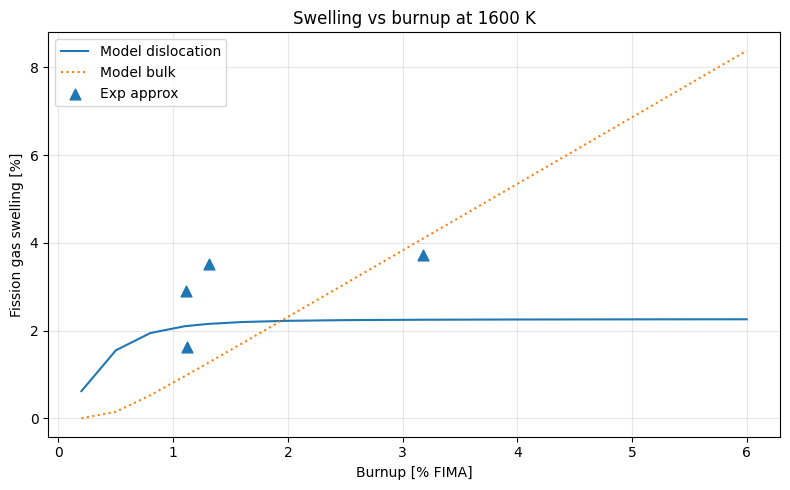

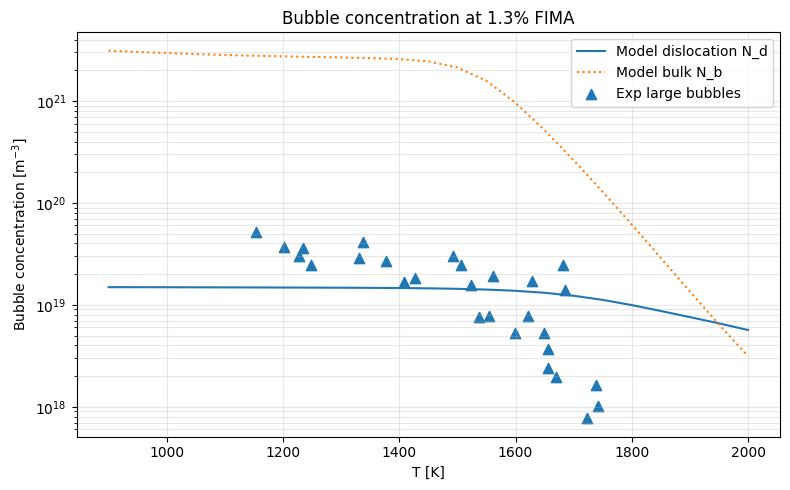

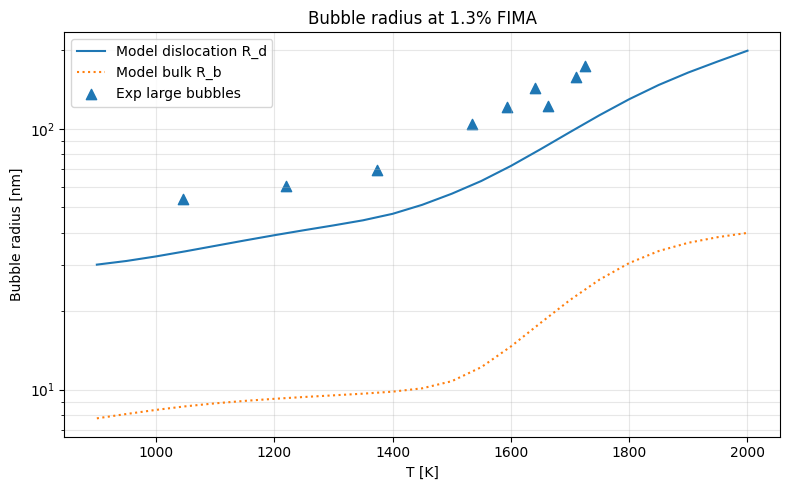

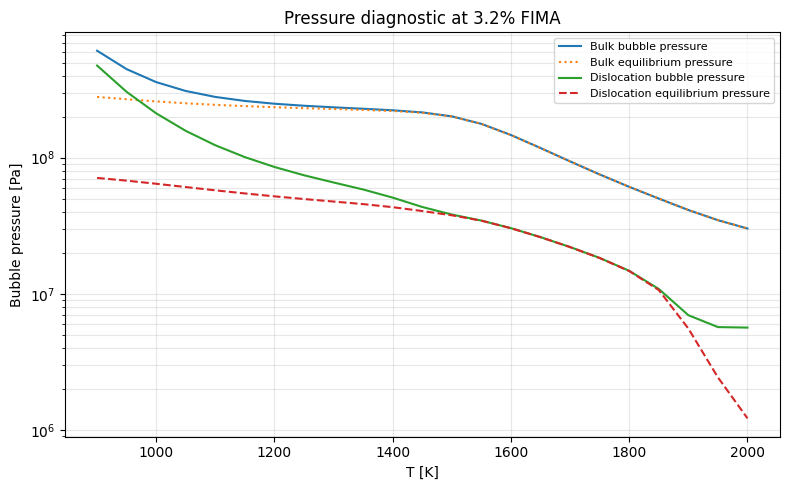

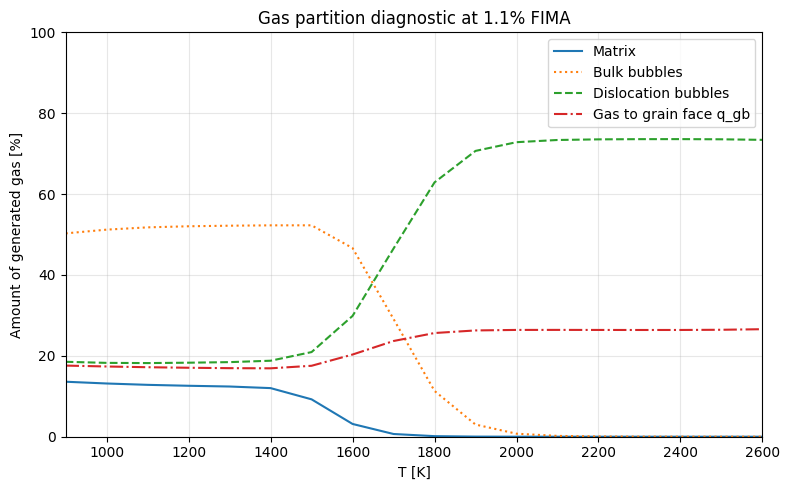

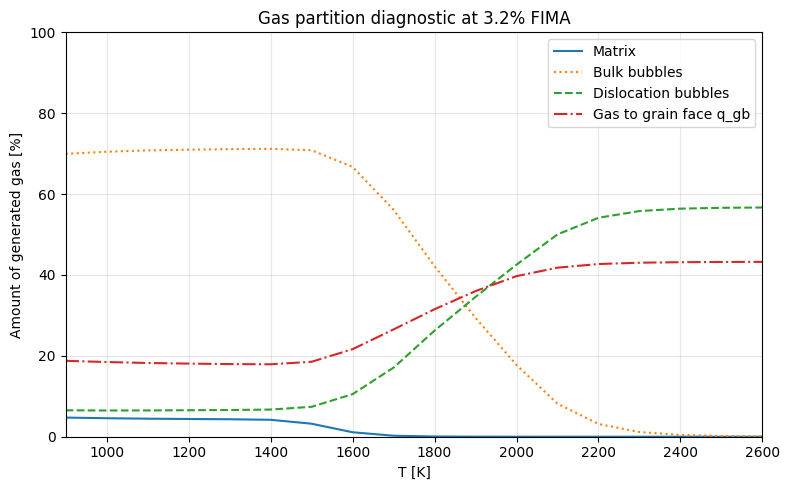


##################################################################################################################################
END CLEAN UN MODEL + f_n CALIBRATION
##################################################################################################################################


In [1]:
import math
from dataclasses import dataclass
from typing import Optional

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

# ============================================================
# CONFIGURAZIONE GENERALE
# ============================================================

FISSION_RATE = 5.0e19
GRAIN_RADIUS = 5.0e-6
K_D_FIXED = 5.0e5
XE_YIELD = 0.24

DT_SCAN_H = 12.0
N_MODES_SCAN = 25

# 0.0 = nessun seed artificiale. Metti 2.0 solo per diagnostica pressione bulk.
BULK_SEED_RADIUS_NM = 0.0

FN_GRID = [
    3.0e-10,
    5.0e-10,
    7.0e-10,
    1.0e-9,
    1.5e-9,
    2.0e-9,
    3.0e-9,
    5.0e-9,
    7.0e-9,
    1.0e-8,
    3.0e-8,
    1.0e-7,
    3.0e-7,
    1.0e-6,
]

# Se vuoi fare solo un test veloce, metti False e usa RUN_SINGLE_TEST=True.
RUN_CALIBRATION = True
RUN_SINGLE_TEST = False

# ============================================================
# DATI SPERIMENTALI DIGITALIZZATI DAL MARKDOWN
# ============================================================

EXP_SWELLING_T = [
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1127.0, "swelling": 0.68},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1228.0, "swelling": 0.59},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1312.0, "swelling": 0.43},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1402.0, "swelling": 0.58},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1485.0, "swelling": 1.22},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1549.0, "swelling": 1.84},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1598.0, "swelling": 1.66},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1632.0, "swelling": 2.13},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1669.0, "swelling": 3.60},
    {"figure": "Fig3a", "burnup": 1.1, "series": "100 kW/m", "T": 1685.0, "swelling": 2.72},

    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 899.0,  "swelling": 0.63},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1154.0, "swelling": 1.17},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1228.0, "swelling": 1.08},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1325.0, "swelling": 1.28},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1435.0, "swelling": 1.32},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1514.0, "swelling": 2.10},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1570.0, "swelling": 2.72},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1608.0, "swelling": 2.91},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1635.0, "swelling": 3.28},
    {"figure": "Fig3a", "burnup": 1.1, "series": "119 kW/m", "T": 1656.0, "swelling": 3.75},

    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1044.0, "swelling": 1.11},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1220.0, "swelling": 1.22},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1377.0, "swelling": 1.33},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1534.0, "swelling": 2.83},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1595.0, "swelling": 3.53},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1639.0, "swelling": 3.86},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1661.0, "swelling": 2.45},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1709.0, "swelling": 2.93},
    {"figure": "Fig3b", "burnup": 1.3, "series": "measurement", "T": 1724.0, "swelling": 3.15},

    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 984.0,  "swelling": 0.72},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1056.0, "swelling": 1.06},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1126.0, "swelling": 1.26},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1247.0, "swelling": 1.58},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1343.0, "swelling": 1.79},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1420.0, "swelling": 2.08},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1459.0, "swelling": 2.40},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1511.0, "swelling": 2.83},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1557.0, "swelling": 3.31},
    {"figure": "Fig3c", "burnup": 3.2, "series": "measurement", "T": 1590.0, "swelling": 3.75},
]

EXP_SWELLING_BURNUP_1600 = [
    {"burnup": 1.12, "swelling": 1.64, "series": "approx 100 kW/m"},
    {"burnup": 1.11, "swelling": 2.90, "series": "approx 119 kW/m"},
    {"burnup": 1.31, "swelling": 3.51, "series": "measurement"},
    {"burnup": 3.18, "swelling": 3.72, "series": "measurement"},
]

EXP_ND_T_13 = [
    {"T": 1153.0, "N": 5.22e19},
    {"T": 1202.0, "N": 3.69e19},
    {"T": 1227.0, "N": 3.00e19},
    {"T": 1235.0, "N": 3.57e19},
    {"T": 1248.0, "N": 2.44e19},
    {"T": 1330.0, "N": 2.90e19},
    {"T": 1338.0, "N": 4.10e19},
    {"T": 1377.0, "N": 2.71e19},
    {"T": 1408.0, "N": 1.67e19},
    {"T": 1427.0, "N": 1.85e19},
    {"T": 1493.0, "N": 3.00e19},
    {"T": 1507.0, "N": 2.44e19},
    {"T": 1524.0, "N": 1.56e19},
    {"T": 1538.0, "N": 7.54e18},
    {"T": 1555.0, "N": 7.80e18},
    {"T": 1561.0, "N": 1.92e19},
    {"T": 1599.0, "N": 5.34e18},
    {"T": 1622.0, "N": 7.80e18},
    {"T": 1628.0, "N": 1.73e19},
    {"T": 1649.0, "N": 5.34e18},
    {"T": 1656.0, "N": 3.65e18},
    {"T": 1656.0, "N": 2.41e18},
    {"T": 1669.0, "N": 1.96e18},
    {"T": 1682.0, "N": 2.44e19},
    {"T": 1685.0, "N": 1.40e19},
    {"T": 1723.0, "N": 7.70e17},
    {"T": 1742.0, "N": 1.02e18},
    {"T": 1739.0, "N": 1.65e18},
]

EXP_RD_T_13 = [
    {"T": 1045.0, "R_nm": 54.06},
    {"T": 1219.0, "R_nm": 60.37},
    {"T": 1374.0, "R_nm": 69.58},
    {"T": 1535.0, "R_nm": 104.85},
    {"T": 1594.0, "R_nm": 120.83},
    {"T": 1641.0, "R_nm": 143.73},
    {"T": 1663.0, "R_nm": 122.76},
    {"T": 1710.0, "R_nm": 157.99},
    {"T": 1725.0, "R_nm": 173.67},
]

# ============================================================
# PARAMETRI E FUNZIONI BASE
# ============================================================

@dataclass
class UNParameters:
    temperature: float = 1600.0
    fission_rate: float = 5.0e19
    grain_radius: float = 5.0e-6
    final_time: float = 24.0 * 3600.0
    target_burnup_percent_fima: Optional[float] = None
    dt: float = 60.0
    n_modes: int = 40

    xe_yield: float = 0.24
    precursor_factor: float = 1.0

    D10: float = 1.56e-3
    Q1: float = 4.94
    A20: float = 1.21e-67
    B21: float = 25.87
    B22: float = -1.49
    B23: float = 0.0
    A30: float = 1.85e-39

    kB_eV: float = 8.617333262e-5
    kB_J: float = 1.380649e-23

    use_sciantix_D2_zero: bool = True

    D10_vU: float = 1.35e-2
    Q1_vU: float = 5.66
    B21_vU_refit: float = -0.62
    B22_vU_refit: float = -0.04
    A20_vU_fig4_refit: float = 4.6304523933553033e-29

    radius_in_lattice: float = 0.21e-9
    omega_fg: float = 8.5e-29
    lattice_parameter: float = 4.889e-10
    gamma_b: float = 1.11
    hydrostatic_stress: float = 0.0
    min_radius_for_pressure: float = 1.0e-15

    f_n: float = 1.0e-6

    rho_d: float = 3.0e13
    K_d: float = 5.0e5
    r_d: float = 3.46e-10
    Z_d: float = 5.0

    R_b: float = 0.0
    N_b: float = 0.0
    R_d: float = 0.0
    N_d: Optional[float] = None

    c0: float = 0.0
    mb0: float = 0.0
    md0: float = 0.0

    nvb0: Optional[float] = None
    nvd0: Optional[float] = None

    diffusivity_sf: float = 1.0
    trapping_sf: float = 1.0
    resolution_sf: float = 1.0

    vacancy_absorption_only: bool = True
    update_bulk_vacancies: bool = True
    min_number_density: float = 0.0
    min_volume: float = 0.0

    bulk_seed_radius_nm: float = 0.0

    def __post_init__(self):
        if self.N_d is None:
            self.N_d = self.K_d * self.rho_d

        if self.target_burnup_percent_fima is not None:
            self.final_time = burnup_percent_to_time(
                self.target_burnup_percent_fima,
                self.fission_rate,
                self.lattice_parameter,
            )


def omega_matrix(p):
    return p.lattice_parameter**3 / 4.0


def uranium_atom_density_from_lattice(lattice_parameter):
    return 4.0 / lattice_parameter**3


def burnup_percent_to_time(burnup_percent_fima, fission_rate, lattice_parameter):
    if fission_rate <= 0.0:
        raise ValueError("fission_rate must be positive to compute time from burnup.")

    burnup_fraction_fima = burnup_percent_fima / 100.0
    uranium_density = uranium_atom_density_from_lattice(lattice_parameter)
    return burnup_fraction_fima * uranium_density / fission_rate


def time_to_burnup_percent(time, fission_rate, lattice_parameter):
    uranium_density = uranium_atom_density_from_lattice(lattice_parameter)
    return 100.0 * fission_rate * time / uranium_density


def sphere_volume(R):
    if R <= 0.0:
        return 0.0
    return (4.0 / 3.0) * math.pi * R**3


def radius_from_volume(V):
    if V <= 0.0:
        return 0.0
    return (3.0 * V / (4.0 * math.pi)) ** (1.0 / 3.0)


def xe_diffusivity_UN(p):
    T = p.temperature
    F = p.fission_rate
    kBT = p.kB_eV * T

    D1 = p.D10 * math.exp(-p.Q1 / kBT)

    if p.use_sciantix_D2_zero:
        D2 = 0.0
    else:
        D2 = p.A20 * math.sqrt(F) * math.exp(
            -p.B21 / kBT
            -p.B22 / (kBT**2)
            -p.B23 / (kBT**3)
        )

    D3 = p.A30 * F
    Dg = (D1 + D2 + D3) * p.diffusivity_sf * p.precursor_factor
    return Dg, {"D1": D1, "D2": D2, "D3": D3, "Dg": Dg}


def vacancy_diffusivity_UN(p):
    T = p.temperature
    F = p.fission_rate
    kBT = p.kB_eV * T

    D1 = p.D10_vU * math.exp(-p.Q1_vU / kBT)
    D2 = math.sqrt(F) * p.A20_vU_fig4_refit * math.exp(
        p.B21_vU_refit / kBT
        + p.B22_vU_refit / (kBT**2)
    )

    Dv = D1 + D2
    return Dv, {"Dv1": D1, "Dv2": D2, "Dv": Dv}


def b0_resolution(R):
    R = max(R, 1.0e-15)
    return 1.0e-25 * (2.64 - 2.02 * math.exp(-2.61e-9 / R))


def resolution_rates_UN(p, R_b, R_d):
    Rb_eff = R_b + p.radius_in_lattice
    Rd_eff = R_d + p.radius_in_lattice

    b_b = p.fission_rate * b0_resolution(Rb_eff) * p.resolution_sf
    b_d = p.fission_rate * b0_resolution(Rd_eff) * p.resolution_sf
    return b_b, b_d


def trapping_rates_UN(p, Dg, R_b, N_b, R_d, N_d):
    Rb_eff = R_b + p.radius_in_lattice
    Rd_eff = R_d + p.radius_in_lattice

    if N_b <= 0.0:
        g_b = 0.0
    else:
        g_b = 4.0 * math.pi * Dg * Rb_eff * N_b

    Gamma_d = 1.0 / math.sqrt(math.pi * p.rho_d)
    den = math.log(Gamma_d / (p.Z_d * p.r_d)) - 3.0 / 5.0

    if den <= 0.0:
        raise ValueError(f"Invalid dislocation sink denominator: {den:g}")

    free_dislocation = max(p.rho_d - 2.0 * R_d * N_d, 0.0)
    term_bubbles = 4.0 * math.pi * Dg * Rd_eff * N_d
    term_dislocation = (2.0 * math.pi * Dg / den) * free_dislocation
    g_d = term_bubbles + term_dislocation

    return p.trapping_sf * g_b, p.trapping_sf * g_d, {
        "Gamma_d": Gamma_d,
        "den": den,
        "free_dislocation": free_dislocation,
        "term_bubbles": term_bubbles,
        "term_dislocation": term_dislocation,
    }


def beta_production(p):
    return p.xe_yield * p.fission_rate


def nucleation_rate_bulk(p, Dg, c):
    return 8.0 * math.pi * p.f_n * Dg * p.omega_fg ** (1.0 / 3.0) * max(c, 0.0) ** 2


def phi_bulk(mb, Nb):
    if Nb <= 0.0:
        return 0.0

    atoms_per_bubble = mb / Nb
    if atoms_per_bubble <= 1.0:
        return 0.0

    return 1.0 / (atoms_per_bubble - 1.0)


def coalescence_lambda(Vd, Nd):
    xi = Vd * Nd
    xi = max(0.0, min(xi, 0.999999))
    return (2.0 - xi) / (2.0 * (1.0 - xi) ** 3)


def pressure_internal(p, m_gas, n_vac):
    if m_gas <= 0.0:
        return 0.0
    if n_vac <= 0.0:
        return math.inf

    denominator = n_vac * omega_matrix(p)
    if denominator <= 0.0:
        return math.inf

    return p.kB_J * p.temperature * m_gas / denominator


def pressure_equilibrium(p, R):
    R_eff = max(R, p.min_radius_for_pressure)
    return 2.0 * p.gamma_b / R_eff - p.hydrostatic_stress


def gas_only_radius_for_population(p, m_gas, N):
    if m_gas <= 0.0 or N <= 0.0:
        return 0.0
    V_gas_per_bubble = p.omega_fg * m_gas / N
    return radius_from_volume(V_gas_per_bubble)


def radius_for_vacancy_update(p, R_old, N, m_gas):
    if R_old > 0.0:
        return R_old
    return gas_only_radius_for_population(p, m_gas, N)


def pressure_equilibrium_for_vacancy_update(p, R_update):
    if R_update <= 0.0:
        return math.inf
    return 2.0 * p.gamma_b / R_update - p.hydrostatic_stress


def wigner_seitz_delta(N):
    return (3.0 / (4.0 * math.pi * max(N, 1.0))) ** (1.0 / 3.0)


def zeta_geometry(R, N):
    delta = wigner_seitz_delta(N)
    psi = max(R / delta, 1.0e-12)
    den = -psi**6 + 5.0 * psi**2 - 9.0 * psi + 5.0

    if den <= 1.0e-30:
        den = 1.0e-30

    return max(10.0 * psi * (1.0 + psi**3) / den, 1.0e-30)


def vacancy_concentration_implicit_step(p, Dv, R, N, m_gas, n_old, dt):
    if N <= 0.0 or m_gas <= 0.0:
        return n_old, 0.0

    R_update = radius_for_vacancy_update(p, R, N, m_gas)
    if R_update <= 0.0:
        return n_old, 0.0

    p_eq = pressure_equilibrium_for_vacancy_update(p, R_update)
    p_int_old = pressure_internal(p, m_gas, n_old)

    if p.vacancy_absorption_only and p_int_old <= p_eq:
        return n_old, 0.0

    delta = wigner_seitz_delta(N)
    zeta = zeta_geometry(R_update, N)

    A = 2.0 * math.pi * Dv * delta * N / (p.kB_J * p.temperature * zeta)
    C = p.kB_J * p.temperature * m_gas / omega_matrix(p)

    B = n_old - dt * A * p_eq
    discriminant = B * B + 4.0 * dt * A * C

    if discriminant < 0.0:
        raise ValueError(f"Negative discriminant in vacancy implicit step: {discriminant:g}")

    sqrt_disc = math.sqrt(discriminant)

    if B >= 0.0:
        n_new = 0.5 * (B + sqrt_disc)
    else:
        denominator = sqrt_disc - B
        if denominator <= 0.0:
            n_new = 0.0
        else:
            n_new = (2.0 * dt * A * C) / denominator

    if p.vacancy_absorption_only:
        n_new = max(n_new, n_old)

    dn_dt = (n_new - n_old) / dt
    return n_new, dn_dt


def initialize_vacancy_concentration(p, N, R, m_gas):
    if N <= 0.0 or R <= 0.0:
        return 0.0

    total_bubble_volume = N * sphere_volume(R)
    gas_volume = p.omega_fg * m_gas
    vacancy_volume = max(total_bubble_volume - gas_volume, 0.0)
    return vacancy_volume / omega_matrix(p)


def initialize_modes_from_average(average, n_modes, n_iter=20):
    modes = [0.0 for _ in range(n_modes)]
    projection_coeff = -math.sqrt(8.0 / math.pi)
    remainder = average

    for _ in range(n_iter):
        reconstructed = 0.0
        for i in range(n_modes):
            n = i + 1
            n_coeff = (-1.0) ** n / n
            modes[i] += projection_coeff * n_coeff * remainder
            reconstructed += projection_coeff * n_coeff * modes[i] * 3.0 / (4.0 * math.pi)
        remainder = average - reconstructed

    return modes


def reconstruct_average(modes):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    average = 0.0

    for i, value in enumerate(modes):
        n = i + 1
        n_coeff = (-1.0) ** n / n
        average += projection_coeff * n_coeff * value / ((4.0 / 3.0) * math.pi)

    return average


def det3(A):
    return (
        A[0][0] * (A[1][1] * A[2][2] - A[1][2] * A[2][1])
        - A[0][1] * (A[1][0] * A[2][2] - A[1][2] * A[2][0])
        + A[0][2] * (A[1][0] * A[2][1] - A[1][1] * A[2][0])
    )


def solve3x3_cramer(A, b):
    detA = det3(A)
    if abs(detA) < 1.0e-300:
        raise ZeroDivisionError("Singular 3x3 system in spectral mode solve")

    Ax = [[b[i], A[i][1], A[i][2]] for i in range(3)]
    Ay = [[A[i][0], b[i], A[i][2]] for i in range(3)]
    Az = [[A[i][0], A[i][1], b[i]] for i in range(3)]

    return [det3(Ax) / detA, det3(Ay) / detA, det3(Az) / detA]


def sciantix_3x3_exchange_step(modes_c, modes_mb, modes_md, Dg, R, beta, g_b, g_d, b_b, b_d, dt):
    projection_coeff = -2.0 * math.sqrt(2.0 / math.pi)
    diffusion_rate_coeff = math.pi**2 * Dg / R**2

    for i in range(len(modes_c)):
        n = i + 1
        n_coeff = (-1.0) ** n / n

        diffusion_rate = diffusion_rate_coeff * n**2
        source_rate = projection_coeff * beta * n_coeff

        A = [
            [1.0 + (diffusion_rate + g_b + g_d) * dt, -b_b * dt, -b_d * dt],
            [-g_b * dt, 1.0 + b_b * dt, 0.0],
            [-g_d * dt, 0.0, 1.0 + b_d * dt],
        ]
        rhs = [modes_c[i] + source_rate * dt, modes_mb[i], modes_md[i]]
        modes_c[i], modes_mb[i], modes_md[i] = solve3x3_cramer(A, rhs)

    return reconstruct_average(modes_c), reconstruct_average(modes_mb), reconstruct_average(modes_md)

# ============================================================
# SOLVER PRINCIPALE UNICO
# ============================================================

def solve_UN_sciantix_intragranular_extended(p):
    modes_c = initialize_modes_from_average(p.c0, p.n_modes)
    modes_mb = initialize_modes_from_average(p.mb0, p.n_modes)
    modes_md = initialize_modes_from_average(p.md0, p.n_modes)

    R_b = p.R_b
    R_d = p.R_d
    N_b = p.N_b
    N_d = p.N_d

    V_b = sphere_volume(R_b)
    V_d = sphere_volume(R_d)

    if p.nvb0 is None:
        nvb = initialize_vacancy_concentration(p, N_b, R_b, p.mb0)
    else:
        nvb = p.nvb0

    if p.nvd0 is None:
        nvd = initialize_vacancy_concentration(p, N_d, R_d, p.md0)
    else:
        nvd = p.nvd0

    beta = beta_production(p)
    initial_gas = p.c0 + p.mb0 + p.md0
    generated = 0.0
    q_gb = 0.0
    retained = initial_gas
    seed_vacancies_added_total = 0.0

    hist = {
        "time": [0.0],
        "burnup_percent_fima": [time_to_burnup_percent(0.0, p.fission_rate, p.lattice_parameter)],
        "c": [reconstruct_average(modes_c)],
        "mb": [reconstruct_average(modes_mb)],
        "md": [reconstruct_average(modes_md)],
        "Nb": [N_b],
        "Nd": [N_d],
        "Vb": [V_b],
        "Vd": [V_d],
        "Rb": [R_b],
        "Rd": [R_d],
        "nvb": [nvb],
        "nvd": [nvd],
        "generated": [generated],
        "retained": [retained],
        "q_gb": [q_gb],
        "qdot_gb": [0.0],
        "swelling_b": [N_b * V_b],
        "swelling_d": [N_d * V_d],
        "swelling_ig": [N_b * V_b + N_d * V_d],
        "p_b": [pressure_internal(p, p.mb0, nvb)],
        "p_d": [pressure_internal(p, p.md0, nvd)],
        "p_b_eq": [pressure_equilibrium(p, R_b)],
        "p_d_eq": [pressure_equilibrium(p, R_d)],
        "lambda_d": [coalescence_lambda(V_d, N_d)],
        "nu_b": [0.0],
        "phi_b": [0.0],
        "dnvb_dt": [0.0],
        "dnvd_dt": [0.0],
        "dVd_growth_dt": [0.0],
        "seed_vacancies_added_total": [0.0],
    }

    last_rates = {}
    n_steps = int(math.ceil(p.final_time / p.dt))

    for _ in range(n_steps):
        t_old = hist["time"][-1]
        dt = min(p.dt, p.final_time - t_old)
        if dt <= 0.0:
            break

        c_old = hist["c"][-1]
        mb_old = hist["mb"][-1]
        md_old = hist["md"][-1]

        Nb_old = N_b
        Nd_old = N_d
        Vd_old = V_d

        Dg, D_parts = xe_diffusivity_UN(p)
        Dv, Dv_parts = vacancy_diffusivity_UN(p)
        b_b, b_d = resolution_rates_UN(p, R_b, R_d)

        g_b_old, g_d, trapping_parts_old = trapping_rates_UN(p, Dg, R_b, Nb_old, R_d, Nd_old)

        # 1. Update N_b prima del gas solver.
        nu_b = nucleation_rate_bulk(p, Dg, c_old)
        phi_b = phi_bulk(mb_old, Nb_old)
        N_b = (Nb_old + dt * nu_b) / (1.0 + dt * b_b * phi_b)
        N_b = max(N_b, p.min_number_density)

        # 2. Seed opzionale per nuove bulk bubbles.
        dN_b_positive = max(N_b - Nb_old, 0.0)
        seed_vacancies_added_step = 0.0
        if dN_b_positive > 0.0 and p.bulk_seed_radius_nm > 0.0:
            V_seed = sphere_volume(p.bulk_seed_radius_nm * 1.0e-9)
            seed_vacancies_added_step = dN_b_positive * V_seed / omega_matrix(p)
            nvb += seed_vacancies_added_step
            seed_vacancies_added_total += seed_vacancies_added_step

        # 3. Correzione importante: ricalcola g_b con N_b aggiornato.
        g_b, _, trapping_parts_updated = trapping_rates_UN(p, Dg, R_b, N_b, R_d, Nd_old)
        trapping_parts = dict(trapping_parts_updated)
        trapping_parts["g_b_old_before_Nb_update"] = g_b_old
        trapping_parts["g_b_used_after_Nb_update"] = g_b
        trapping_parts["Nb_old"] = Nb_old
        trapping_parts["Nb_used_for_gb"] = N_b

        # 4. Gas solver.
        c_new, mb_new, md_new = sciantix_3x3_exchange_step(
            modes_c, modes_mb, modes_md,
            Dg, p.grain_radius, beta,
            g_b, g_d, b_b, b_d, dt,
        )

        dmb_dt = (mb_new - mb_old) / dt
        dmd_dt = (md_new - md_old) / dt

        # 5. Vacancy update.
        if p.update_bulk_vacancies:
            nvb, dnvb_dt = vacancy_concentration_implicit_step(p, Dv, R_b, N_b, mb_new, nvb, dt)
        else:
            dnvb_dt = 0.0

        nvd, dnvd_dt = vacancy_concentration_implicit_step(p, Dv, R_d, Nd_old, md_new, nvd, dt)

        # 6. Volume growth prima della coalescenza.
        if N_b > 0.0:
            V_b_growth = V_b + dt * (
                p.omega_fg / N_b * dmb_dt + omega_matrix(p) / N_b * dnvb_dt
            )
            V_b_growth = max(V_b_growth, p.min_volume)
        else:
            V_b_growth = V_b

        if Nd_old > 0.0:
            dVd_growth_dt = p.omega_fg / Nd_old * dmd_dt + omega_matrix(p) / Nd_old * dnvd_dt
            V_d_growth = V_d + dt * dVd_growth_dt
            V_d_growth = max(V_d_growth, p.min_volume)
        else:
            dVd_growth_dt = 0.0
            V_d_growth = V_d

        # 7. Coalescenza dislocation bubbles.
        lambda_d = coalescence_lambda(Vd_old, Nd_old)
        dVd_positive = max(V_d_growth - Vd_old, 0.0)
        if dVd_positive > 0.0 and Nd_old > 0.0:
            N_d = Nd_old / (1.0 + 4.0 * lambda_d * Nd_old * dVd_positive)
        else:
            N_d = Nd_old
        N_d = max(N_d, p.min_number_density)

        # 8. Ricostruzione volumi da gas + vacancies.
        if N_b > 0.0:
            V_b = (p.omega_fg * max(mb_new, 0.0) + omega_matrix(p) * nvb) / N_b
        else:
            V_b = 0.0

        if N_d > 0.0:
            V_d = (p.omega_fg * max(md_new, 0.0) + omega_matrix(p) * nvd) / N_d
        else:
            V_d = 0.0

        V_b = max(V_b, p.min_volume)
        V_d = max(V_d, p.min_volume)
        R_b = radius_from_volume(V_b)
        R_d = radius_from_volume(V_d)

        # 9. Bilancio gas a grain face.
        generated += beta * dt
        retained = c_new + mb_new + md_new
        q_gb_old = q_gb
        q_gb = max(initial_gas + generated - retained, 0.0)
        qdot_gb = max((q_gb - q_gb_old) / dt, 0.0)

        hist["time"].append(t_old + dt)
        hist["burnup_percent_fima"].append(time_to_burnup_percent(t_old + dt, p.fission_rate, p.lattice_parameter))
        hist["c"].append(c_new)
        hist["mb"].append(mb_new)
        hist["md"].append(md_new)
        hist["Nb"].append(N_b)
        hist["Nd"].append(N_d)
        hist["Vb"].append(V_b)
        hist["Vd"].append(V_d)
        hist["Rb"].append(R_b)
        hist["Rd"].append(R_d)
        hist["nvb"].append(nvb)
        hist["nvd"].append(nvd)
        hist["generated"].append(generated)
        hist["retained"].append(retained)
        hist["q_gb"].append(q_gb)
        hist["qdot_gb"].append(qdot_gb)
        hist["swelling_b"].append(N_b * V_b)
        hist["swelling_d"].append(N_d * V_d)
        hist["swelling_ig"].append(N_b * V_b + N_d * V_d)
        hist["p_b"].append(pressure_internal(p, mb_new, nvb))
        hist["p_d"].append(pressure_internal(p, md_new, nvd))
        hist["p_b_eq"].append(pressure_equilibrium(p, R_b))
        hist["p_d_eq"].append(pressure_equilibrium(p, R_d))
        hist["lambda_d"].append(lambda_d)
        hist["nu_b"].append(nu_b)
        hist["phi_b"].append(phi_b)
        hist["dnvb_dt"].append(dnvb_dt)
        hist["dnvd_dt"].append(dnvd_dt)
        hist["dVd_growth_dt"].append(dVd_growth_dt)
        hist["seed_vacancies_added_total"].append(seed_vacancies_added_total)

        last_rates = {
            "Dg": Dg,
            "Dv": Dv,
            "beta": beta,
            "g_b": g_b,
            "g_b_old_before_Nb_update": g_b_old,
            "g_d": g_d,
            "b_b": b_b,
            "b_d": b_d,
            "nu_b": nu_b,
            "phi_b": phi_b,
            "lambda_d": lambda_d,
            "dVd_growth_dt": dVd_growth_dt,
            "dnvb_dt": dnvb_dt,
            "dnvd_dt": dnvd_dt,
            "seed_vacancies_added_step": seed_vacancies_added_step,
            "seed_vacancies_added_total": seed_vacancies_added_total,
            "p_b": pressure_internal(p, mb_new, nvb),
            "p_d": pressure_internal(p, md_new, nvd),
            "p_b_eq": pressure_equilibrium(p, R_b),
            "p_d_eq": pressure_equilibrium(p, R_d),
            "Nb_old": Nb_old,
            "Nb_updated_before_gas": N_b,
            "Nd_old": Nd_old,
            "Nd_after_coalescence": N_d,
            **D_parts,
            **Dv_parts,
            **trapping_parts,
        }

    return hist, last_rates

# ============================================================
# WRAPPER E SCORE
# ============================================================

_RUN_CACHE = {}


def run_model_point(T, burnup, f_n, bulk_seed_radius_nm=BULK_SEED_RADIUS_NM, dt_h=DT_SCAN_H, n_modes=N_MODES_SCAN):
    key = (
        round(float(T), 6),
        round(float(burnup), 6),
        float(f_n),
        float(bulk_seed_radius_nm),
        float(dt_h),
        int(n_modes),
    )
    if key in _RUN_CACHE:
        return _RUN_CACHE[key]

    p = UNParameters(
        temperature=float(T),
        fission_rate=FISSION_RATE,
        grain_radius=GRAIN_RADIUS,
        target_burnup_percent_fima=float(burnup),
        dt=float(dt_h) * 3600.0,
        n_modes=int(n_modes),
        xe_yield=XE_YIELD,
        f_n=float(f_n),
        K_d=K_D_FIXED,
        R_b=0.0,
        N_b=0.0,
        R_d=0.0,
        N_d=None,
        c0=0.0,
        mb0=0.0,
        md0=0.0,
        vacancy_absorption_only=True,
        update_bulk_vacancies=True,
        bulk_seed_radius_nm=float(bulk_seed_radius_nm),
    )

    hist, rates = solve_UN_sciantix_intragranular_extended(p)

    generated = hist["generated"][-1]
    if generated > 0.0:
        matrix_gas_percent = 100.0 * hist["c"][-1] / generated
        bulk_gas_percent = 100.0 * hist["mb"][-1] / generated
        dislocation_gas_percent = 100.0 * hist["md"][-1] / generated
        qgb_gas_percent = 100.0 * hist["q_gb"][-1] / generated
    else:
        matrix_gas_percent = bulk_gas_percent = dislocation_gas_percent = qgb_gas_percent = 0.0

    p_b_eq = hist["p_b_eq"][-1]
    p_d_eq = hist["p_d_eq"][-1]

    row = {
        "T": float(T),
        "burnup": float(burnup),
        "f_n": float(f_n),
        "bulk_seed_radius_nm": float(bulk_seed_radius_nm),
        "swelling_b_percent": 100.0 * hist["swelling_b"][-1],
        "swelling_d_percent": 100.0 * hist["swelling_d"][-1],
        "swelling_ig_percent": 100.0 * hist["swelling_ig"][-1],
        "Nb": hist["Nb"][-1],
        "Nd": hist["Nd"][-1],
        "Rb_nm": hist["Rb"][-1] * 1.0e9,
        "Rd_nm": hist["Rd"][-1] * 1.0e9,
        "p_b": hist["p_b"][-1],
        "p_b_eq": p_b_eq,
        "p_d": hist["p_d"][-1],
        "p_d_eq": p_d_eq,
        "p_b_over_eq": hist["p_b"][-1] / p_b_eq if p_b_eq > 0.0 else math.nan,
        "p_d_over_eq": hist["p_d"][-1] / p_d_eq if p_d_eq > 0.0 else math.nan,
        "matrix_gas_percent": matrix_gas_percent,
        "bulk_gas_percent": bulk_gas_percent,
        "dislocation_gas_percent": dislocation_gas_percent,
        "qgb_gas_percent": qgb_gas_percent,
        "Dg": rates.get("Dg", math.nan),
        "Dv": rates.get("Dv", math.nan),
        "g_b": rates.get("g_b", math.nan),
        "g_d": rates.get("g_d", math.nan),
        "hist": hist,
        "rates": rates,
    }

    _RUN_CACHE[key] = row
    return row


def rmse(values):
    values = [v for v in values if math.isfinite(v)]
    if not values:
        return math.nan
    return math.sqrt(sum(v * v for v in values) / len(values))


def log10_rmse(pairs):
    errs = []
    for pred, exp in pairs:
        if pred > 0.0 and exp > 0.0 and math.isfinite(pred) and math.isfinite(exp):
            errs.append(math.log10(pred / exp))
    return rmse(errs)


def score_combo(f_n):
    swelling_errors = []
    for exp in EXP_SWELLING_T:
        out = run_model_point(exp["T"], exp["burnup"], f_n)
        swelling_errors.append(out["swelling_d_percent"] - exp["swelling"])

    score_swelling = rmse(swelling_errors)

    n_pairs = []
    for exp in EXP_ND_T_13:
        out = run_model_point(exp["T"], 1.3, f_n)
        n_pairs.append((out["Nd"], exp["N"]))

    r_pairs = []
    for exp in EXP_RD_T_13:
        out = run_model_point(exp["T"], 1.3, f_n)
        r_pairs.append((out["Rd_nm"], exp["R_nm"]))

    score_log_N = log10_rmse(n_pairs)
    score_log_R = log10_rmse(r_pairs)

    # Penalità leggera per pressioni troppo lontane da equilibrio a bassa T.
    p_low = run_model_point(984.0, 3.2, f_n)
    pressure_penalty = 0.0
    if p_low["p_b_over_eq"] > 0.0 and p_low["p_d_over_eq"] > 0.0:
        pressure_penalty = 0.15 * (
            abs(math.log10(max(p_low["p_b_over_eq"], 1.0e-30)))
            + abs(math.log10(max(p_low["p_d_over_eq"], 1.0e-30)))
        )

    total_score = score_swelling + score_log_N + score_log_R + pressure_penalty

    return {
        "f_n": f_n,
        "score_total": total_score,
        "score_swelling_rmse_percent": score_swelling,
        "score_log10_N": score_log_N,
        "score_log10_R": score_log_R,
        "pressure_penalty": pressure_penalty,
    }


def print_ranking(rows):
    rows_sorted = sorted(rows, key=lambda r: r["score_total"])
    print("\n" + "=" * 130)
    print("RANKING f_n ONLY, K_d FIXED")
    print("=" * 130)
    print(
        f"{'rank':>4s} | {'score':>12s} | {'RMSE_sw_%':>12s} | "
        f"{'logRMSE_N':>12s} | {'logRMSE_R':>12s} | {'p_penalty':>12s} | {'f_n':>12s}"
    )
    print("-" * 130)

    for i, r in enumerate(rows_sorted, start=1):
        print(
            f"{i:4d} | {r['score_total']:12.5e} | "
            f"{r['score_swelling_rmse_percent']:12.5e} | "
            f"{r['score_log10_N']:12.5e} | "
            f"{r['score_log10_R']:12.5e} | "
            f"{r['pressure_penalty']:12.5e} | "
            f"{r['f_n']:12.3e}"
        )

    return rows_sorted

# ============================================================
# OUTPUT E GRAFICI
# ============================================================

def print_key_table(title, rows):
    print("\n" + "=" * 170)
    print(title)
    print("=" * 170)
    print(
        f"{'T_K':>8s} | {'sw_b_%':>10s} | {'sw_d_%':>10s} | {'sw_ig_%':>10s} | "
        f"{'Rb_nm':>10s} | {'Rd_nm':>10s} | {'Nb':>12s} | {'Nd':>12s} | "
        f"{'pb/peq':>10s} | {'pd/peq':>10s} | "
        f"{'matrix_%':>10s} | {'bulkGas_%':>10s} | {'dislGas_%':>10s} | {'qgb_%':>10s}"
    )
    print("-" * 170)

    wanted = {900.0, 1000.0, 1200.0, 1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 2000.0}
    for r in rows:
        if r["T"] in wanted:
            print(
                f"{r['T']:8.1f} | "
                f"{r['swelling_b_percent']:10.4e} | {r['swelling_d_percent']:10.4e} | {r['swelling_ig_percent']:10.4e} | "
                f"{r['Rb_nm']:10.4e} | {r['Rd_nm']:10.4e} | "
                f"{r['Nb']:12.5e} | {r['Nd']:12.5e} | "
                f"{r['p_b_over_eq']:10.4e} | {r['p_d_over_eq']:10.4e} | "
                f"{r['matrix_gas_percent']:10.4e} | {r['bulk_gas_percent']:10.4e} | "
                f"{r['dislocation_gas_percent']:10.4e} | {r['qgb_gas_percent']:10.4e}"
            )


def plot_exp_swelling_for_burnup(bu):
    series_names = sorted({p["series"] for p in EXP_SWELLING_T if abs(p["burnup"] - bu) < 1.0e-9})
    for series in series_names:
        pts = [p for p in EXP_SWELLING_T if abs(p["burnup"] - bu) < 1.0e-9 and p["series"] == series]
        marker = "x" if "119" in series else "^"
        plt.scatter([p["T"] for p in pts], [p["swelling"] for p in pts], marker=marker, s=55, label=f"Exp {series}")


def make_diagnostics(best_fn):
    T_PLOT = [float(T) for T in range(900, 2001, 50)]
    T_AMOUNT = [float(T) for T in range(900, 2601, 100)]
    BURNUPS = [1.1, 1.3, 3.2]

    results_by_burnup = {}
    for bu in BURNUPS:
        results_by_burnup[bu] = [run_model_point(T, bu, best_fn) for T in T_PLOT]
        print_key_table(f"DETAILED TABLE - f_n={best_fn:.3e}, burnup={bu:.1f}% FIMA", results_by_burnup[bu])

    gas_partition = {}
    for bu in [1.1, 3.2]:
        gas_partition[bu] = [run_model_point(T, bu, best_fn) for T in T_AMOUNT]

    if plt is None:
        print("\nmatplotlib non installato: grafici saltati.")
        return

    for bu in BURNUPS:
        rows = results_by_burnup[bu]
        Ts = [r["T"] for r in rows]
        plt.figure(figsize=(8, 5))
        plt.plot(Ts, [r["swelling_d_percent"] for r in rows], label="Model dislocation")
        plt.plot(Ts, [r["swelling_b_percent"] for r in rows], linestyle=":", label="Model bulk")
        plot_exp_swelling_for_burnup(bu)
        plt.xlabel("T [K]")
        plt.ylabel("Fission gas swelling [%]")
        plt.title(f"Swelling vs T at {bu:.1f}% FIMA; f_n={best_fn:.2e}, K_d={K_D_FIXED:.1e}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    burnup_grid = [0.2, 0.5, 0.8, 1.1, 1.3, 1.6, 2.0, 2.5, 3.2, 4.0, 5.0, 6.0]
    rows_bu = [run_model_point(1600.0, bu, best_fn) for bu in burnup_grid]
    plt.figure(figsize=(8, 5))
    plt.plot(burnup_grid, [r["swelling_d_percent"] for r in rows_bu], label="Model dislocation")
    plt.plot(burnup_grid, [r["swelling_b_percent"] for r in rows_bu], linestyle=":", label="Model bulk")
    plt.scatter([p["burnup"] for p in EXP_SWELLING_BURNUP_1600], [p["swelling"] for p in EXP_SWELLING_BURNUP_1600], marker="^", s=60, label="Exp approx")
    plt.xlabel("Burnup [% FIMA]")
    plt.ylabel("Fission gas swelling [%]")
    plt.title("Swelling vs burnup at 1600 K")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    rows = results_by_burnup[1.3]
    Ts = [r["T"] for r in rows]
    plt.figure(figsize=(8, 5))
    plt.plot(Ts, [r["Nd"] for r in rows], label="Model dislocation N_d")
    plt.plot(Ts, [r["Nb"] for r in rows], linestyle=":", label="Model bulk N_b")
    plt.scatter([p["T"] for p in EXP_ND_T_13], [p["N"] for p in EXP_ND_T_13], marker="^", s=55, label="Exp large bubbles")
    plt.yscale("log")
    plt.xlabel("T [K]")
    plt.ylabel("Bubble concentration [m$^{-3}$]")
    plt.title("Bubble concentration at 1.3% FIMA")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(Ts, [r["Rd_nm"] for r in rows], label="Model dislocation R_d")
    plt.plot(Ts, [r["Rb_nm"] for r in rows], linestyle=":", label="Model bulk R_b")
    plt.scatter([p["T"] for p in EXP_RD_T_13], [p["R_nm"] for p in EXP_RD_T_13], marker="^", s=55, label="Exp large bubbles")
    plt.yscale("log")
    plt.xlabel("T [K]")
    plt.ylabel("Bubble radius [nm]")
    plt.title("Bubble radius at 1.3% FIMA")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    rows = results_by_burnup[3.2]
    Ts = [r["T"] for r in rows]
    plt.figure(figsize=(8, 5))
    plt.plot(Ts, [r["p_b"] for r in rows], label="Bulk bubble pressure")
    plt.plot(Ts, [r["p_b_eq"] for r in rows], linestyle=":", label="Bulk equilibrium pressure")
    plt.plot(Ts, [r["p_d"] for r in rows], label="Dislocation bubble pressure")
    plt.plot(Ts, [r["p_d_eq"] for r in rows], linestyle="--", label="Dislocation equilibrium pressure")
    plt.yscale("log")
    plt.xlabel("T [K]")
    plt.ylabel("Bubble pressure [Pa]")
    plt.title("Pressure diagnostic at 3.2% FIMA")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    for bu, rows in gas_partition.items():
        Ts = [r["T"] for r in rows]
        plt.figure(figsize=(8, 5))
        plt.plot(Ts, [r["matrix_gas_percent"] for r in rows], label="Matrix")
        plt.plot(Ts, [r["bulk_gas_percent"] for r in rows], linestyle=":", label="Bulk bubbles")
        plt.plot(Ts, [r["dislocation_gas_percent"] for r in rows], linestyle="--", label="Dislocation bubbles")
        plt.plot(Ts, [r["qgb_gas_percent"] for r in rows], linestyle="-.", label="Gas to grain face q_gb")
        plt.xlabel("T [K]")
        plt.ylabel("Amount of generated gas [%]")
        plt.title(f"Gas partition diagnostic at {bu:.1f}% FIMA")
        plt.xlim(900, 2600)
        plt.ylim(0, 100)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

# ============================================================
# MAIN
# ============================================================

if RUN_SINGLE_TEST:
    test = run_model_point(1600.0, 1.3, 3.0e-9)
    print(test)

if RUN_CALIBRATION:
    print("\n" + "#" * 130)
    print("START CLEAN UN MODEL + f_n CALIBRATION")
    print("#" * 130)
    print(f"K_d fixed             = {K_D_FIXED:.6e} bub/m")
    print(f"rho_d default         = 3.0e13 m^-2")
    print(f"N_d0                  = {K_D_FIXED * 3.0e13:.6e} bub/m3")
    print(f"Xe yield              = {XE_YIELD:.6e}")
    print(f"dt scan               = {DT_SCAN_H:.2f} h")
    print(f"n_modes               = {N_MODES_SCAN:d}")
    print(f"bulk seed radius      = {BULK_SEED_RADIUS_NM:.3f} nm")
    print("Target principale: experimental large/P2 bubbles -> model dislocation bubbles.")

    ranking = []
    for f_n in FN_GRID:
        print(f"Running f_n = {f_n:.3e}")
        ranking.append(score_combo(f_n))

    ranking_sorted = print_ranking(ranking)
    best_fn = ranking_sorted[0]["f_n"]

    print("\n" + "=" * 130)
    print("SELECTED PARAMETER SET")
    print("=" * 130)
    print(f"best f_n              = {best_fn:.6e}")
    print(f"K_d                   = {K_D_FIXED:.6e} bub/m")
    print(f"bulk seed radius      = {BULK_SEED_RADIUS_NM:.3f} nm")
    print("=" * 130)

    make_diagnostics(best_fn)

    print("\n" + "#" * 130)
    print("END CLEAN UN MODEL + f_n CALIBRATION")
    print("#" * 130)
